## Import 

In [1]:
import sys
from pathlib import Path

# Add src directory to path
notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent
src_dir = parent_dir / 'src'
sys.path.insert(0, str(src_dir))

import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Working directory: {Path.cwd()}")
print(f"Source directory: {src_dir}")

Libraries imported successfully!
Working directory: d:\Tsinghua Classes and Papers\Network Science\migra-net-china\Clean Code
Source directory: d:\Tsinghua Classes and Papers\Network Science\migra-net-china\src


## Get Files and Graphs

In [2]:
from graph import create_directed_graph, create_undirected_graph

# Create directed and undirected graphs

## Network Metrics

In [3]:
# ========== HELPER FUNCTIONS FOR NETWORK METRICS ==========

def compute_global_metrics(G):
    """
    Compute basic topological properties of the network.
    """
    metrics = {}
    
    # Basic properties
    metrics['n_nodes'] = G.number_of_nodes()
    metrics['n_edges'] = G.number_of_edges()
    
    if metrics['n_nodes'] <= 1:
        return metrics
    
    # Density and degree
    metrics['density'] = nx.density(G)
    degrees = [d for n, d in G.degree()]
    metrics['avg_degree'] = np.mean(degrees) if degrees else 0
    metrics['max_degree'] = max(degrees) if degrees else 0
    
    # Path length and diameter (on largest connected component)
    if nx.is_connected(G):
        metrics['avg_path_length'] = nx.average_shortest_path_length(G)
        metrics['diameter'] = nx.diameter(G)
        metrics['lcc_fraction'] = 1.0
    else:
        # Get largest connected component
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        if len(largest_cc) > 1:
            metrics['avg_path_length'] = nx.average_shortest_path_length(subgraph)
            metrics['diameter'] = nx.diameter(subgraph)
        else:
            metrics['avg_path_length'] = 0
            metrics['diameter'] = 0
        metrics['lcc_fraction'] = len(largest_cc) / metrics['n_nodes']
    
    # Clustering
    metrics['avg_clustering'] = nx.average_clustering(G)
    metrics['transitivity'] = nx.transitivity(G)
    
    # Assortativity
    try:
        metrics['assortativity'] = nx.degree_assortativity_coefficient(G)
    except:
        metrics['assortativity'] = np.nan
    
    return metrics


def detect_communities(G):
    """
    Detect communities using Louvain algorithm (or greedy modularity as fallback).
    Returns partition dict and modularity score.
    """
    try:
        import community as community_louvain
        partition = community_louvain.best_partition(G, weight='weight')
        modularity = community_louvain.modularity(partition, G, weight='weight')
    except ImportError:
        # Fallback to greedy modularity
        communities = nx.community.greedy_modularity_communities(G, weight='weight')
        partition = {}
        for i, community in enumerate(communities):
            for node in community:
                partition[node] = i
        modularity = nx.community.modularity(G, communities, weight='weight')
    
    return partition, modularity


def compute_hub_measures(G, partition):
    """
    Compute gateway-ness (B), provincial-ness (Z), and connector-ness (P)
    for all nodes in the network.
    """
    measures = {}
    
    # Group nodes by community
    communities = defaultdict(list)
    for node, comm in partition.items():
        communities[comm].append(node)
    
    for node in G.nodes():
        node_comm = partition[node]
        neighbors = list(G.neighbors(node))
        
        if len(neighbors) == 0:
            measures[node] = {'B': 0, 'Z': 0, 'P': 0}
            continue
        
        # Count inside-module and outside-module connections
        k_inside = sum(1 for n in neighbors if partition[n] == node_comm)
        k_outside = sum(1 for n in neighbors if partition[n] != node_comm)
        
        # Compute Z-score for inside-module degree (Provincial-ness)
        community_nodes = communities[node_comm]
        k_inside_values = []
        for n in community_nodes:
            if n in G:
                n_neighbors = list(G.neighbors(n))
                k_inside_n = sum(1 for nn in n_neighbors if partition[nn] == node_comm)
                k_inside_values.append(k_inside_n)
        
        if len(k_inside_values) > 1:
            mean_k_inside = np.mean(k_inside_values)
            std_k_inside = np.std(k_inside_values)
            Z = (k_inside - mean_k_inside) / std_k_inside if std_k_inside > 0 else 0
        else:
            Z = 0
        
        # Compute Z-score for outside-module degree (Gateway-ness)
        k_outside_values = []
        for n in community_nodes:
            if n in G:
                n_neighbors = list(G.neighbors(n))
                k_outside_n = sum(1 for nn in n_neighbors if partition[nn] != node_comm)
                k_outside_values.append(k_outside_n)
        
        if len(k_outside_values) > 1:
            mean_k_outside = np.mean(k_outside_values)
            std_k_outside = np.std(k_outside_values)
            B = (k_outside - mean_k_outside) / std_k_outside if std_k_outside > 0 else 0
        else:
            B = 0
        
        # Compute participation coefficient (Connector-ness)
        k_total = len(neighbors)
        k_per_module = defaultdict(int)
        for n in neighbors:
            k_per_module[partition[n]] += 1
        
        P = 1 - sum((k_s / k_total) ** 2 for k_s in k_per_module.values())
        
        measures[node] = {'B': B, 'Z': Z, 'P': P}
    
    return measures


def classify_hubs(hub_measures, B_threshold=1.5, Z_threshold=1.5, P_threshold=0.7):
    """
    Classify nodes as gateway, provincial, or connector hubs.
    """
    gateway_hubs = []
    provincial_hubs = []
    connector_hubs = []
    
    for node, measures in hub_measures.items():
        if measures['B'] >= B_threshold:
            gateway_hubs.append(node)
        if measures['Z'] >= Z_threshold:
            provincial_hubs.append(node)
        if measures['P'] >= P_threshold:
            connector_hubs.append(node)
    
    return {
        'gateway': gateway_hubs,
        'provincial': provincial_hubs,
        'connector': connector_hubs
    }

print("Helper functions defined successfully!")

Helper functions defined successfully!


In [4]:
# ========== MAIN COMPUTATION FUNCTION ==========

def compute_all_metrics_for_config(granularity, years=None):
    """
    Compute all network metrics for a given granularity and year(s).
    
    Args:
        granularity: "county", "prefecture", or "province"
        years: list of years, or None for all years combined
        
    Returns:
        Dictionary with all computed metrics
    """
    print(f"\nComputing metrics for granularity={granularity}, years={years}")
    
    # Create graph
    G = create_undirected_graph(granularity=granularity, years=years)
    
    if G.number_of_nodes() < 10:
        print(f"  Warning: Graph has only {G.number_of_nodes()} nodes, skipping analysis")
        return None
    
    print(f"  Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    results = {
        'granularity': granularity,
        'years': str(years) if years else 'all'
    }
    
    # 1. Global metrics
    print("  Computing global metrics...")
    global_metrics = compute_global_metrics(G)
    results.update(global_metrics)
    
    # 2. Community detection
    print("  Detecting communities...")
    partition, modularity = detect_communities(G)
    n_communities = len(set(partition.values()))
    results['modularity'] = modularity
    results['n_communities'] = n_communities
    
    # 3. Hub measures
    print("  Computing hub measures...")
    hub_measures = compute_hub_measures(G, partition)
    hub_classification = classify_hubs(hub_measures)
    results['n_gateway_hubs'] = len(hub_classification['gateway'])
    results['n_provincial_hubs'] = len(hub_classification['provincial'])
    results['n_connector_hubs'] = len(hub_classification['connector'])
    
    # Store top hubs
    top_B = sorted(hub_measures.items(), key=lambda x: x[1]['B'], reverse=True)[:5]
    top_Z = sorted(hub_measures.items(), key=lambda x: x[1]['Z'], reverse=True)[:5]
    top_P = sorted(hub_measures.items(), key=lambda x: x[1]['P'], reverse=True)[:5]
    
    results['top_gateway_hubs'] = [str(node) for node, _ in top_B]
    results['top_provincial_hubs'] = [str(node) for node, _ in top_Z]
    results['top_connector_hubs'] = [str(node) for node, _ in top_P]
    
    print(f"  ✓ Completed: Q={modularity:.3f}, {n_communities} communities")
    
    return results


def compute_metrics_across_granularities_and_years(granularities, year_list=None):
    """
    Compute metrics across different granularities and years.
    
    Args:
        granularities: list of granularities ["county", "prefecture", "province"]
        year_list: list of years to analyze, or None for aggregate only
        
    Returns:
        DataFrame with all metrics
    """
    all_results = []
    
    # Compute for each granularity with all years combined
    print("\n" + "="*60)
    print("COMPUTING METRICS FOR ALL YEARS COMBINED")
    print("="*60)
    for granularity in granularities:
        result = compute_all_metrics_for_config(granularity, years=None)
        if result:
            all_results.append(result)
    
    # Compute for each granularity and year combination
    if year_list:
        print("\n" + "="*60)
        print("COMPUTING METRICS FOR INDIVIDUAL YEARS")
        print("="*60)
        for granularity in granularities:
            for year in year_list:
                result = compute_all_metrics_for_config(granularity, years=[year])
                if result:
                    result['year'] = year
                    all_results.append(result)
    
    # Convert to DataFrame
    df = pd.DataFrame(all_results)
    
    # Reorder columns
    priority_cols = ['granularity', 'years', 'year', 'n_nodes', 'n_edges', 'density', 
                     'avg_degree', 'modularity', 'n_communities']
    other_cols = [col for col in df.columns if col not in priority_cols]
    df = df[[col for col in priority_cols if col in df.columns] + other_cols]
    
    return df

print("Main computation functions defined!")

Main computation functions defined!


## Compute Metrics for All Granularities and Years

In [5]:
# Define granularities to analyze
granularities = ["county", "prefecture", "province"]

# Define years to analyze individually (sample years)
# Modify this list to include more years or set to None for aggregate only
sample_years = [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]

# Compute metrics across all configurations
metrics_df = compute_metrics_across_granularities_and_years(
    granularities=granularities,
    year_list=sample_years  # Set to None to only compute aggregate metrics (faster)
)

# Display summary
print("\n" + "="*80)
print("METRICS SUMMARY")
print("="*80)
display(metrics_df[['granularity', 'years', 'year', 'n_nodes', 'n_edges', 'density', 
                     'modularity', 'n_communities', 'n_gateway_hubs', 
                     'n_provincial_hubs', 'n_connector_hubs']])

# Save to CSV
metrics_df.to_csv('network_metrics_all_granularities.csv', index=False)
print("\n✓ Results saved to: network_metrics_all_granularities.csv")

# Display full dataframe
metrics_df


COMPUTING METRICS FOR ALL YEARS COMBINED

Computing metrics for granularity=county, years=None
  Graph: 2697 nodes, 83069 edges
  Computing global metrics...
  Detecting communities...
  Computing hub measures...
  ✓ Completed: Q=0.549, 12 communities

Computing metrics for granularity=prefecture, years=None
  Graph: 331 nodes, 16518 edges
  Computing global metrics...
  Detecting communities...
  Computing hub measures...
  ✓ Completed: Q=0.460, 7 communities

Computing metrics for granularity=province, years=None
  Graph: 31 nodes, 465 edges
  Computing global metrics...
  Detecting communities...
  Computing hub measures...
  ✓ Completed: Q=0.281, 4 communities

COMPUTING METRICS FOR INDIVIDUAL YEARS

Computing metrics for granularity=county, years=[2000]
  Graph: 2205 nodes, 5713 edges
  Computing global metrics...
  Detecting communities...
  Computing hub measures...
  ✓ Completed: Q=0.600, 29 communities

Computing metrics for granularity=county, years=[2001]
  Graph: 1779 node

,granularity,years,year,n_nodes,n_edges,density,modularity,n_communities,n_gateway_hubs,n_provincial_hubs,n_connector_hubs
0,county,all,NaN,2697,83069,0.022849,0.549161,12,171,207,880
1,prefecture,all,NaN,331,16518,0.302444,0.459945,7,33,30,280
2,province,all,NaN,31,465,1.000000,0.281315,4,0,0,22
3,county,[2000],2000.0,2205,5713,0.002351,0.599584,29,124,144,131
4,county,[2001],2001.0,1779,2941,0.001860,0.685416,55,88,117,47
5,county,[2002],2002.0,2019,4165,0.002045,0.626277,41,117,137,112
6,county,[2003],2003.0,2087,4798,0.002204,0.595858,27,133,135,102
7,county,[2004],2004.0,2047,4324,0.002065,0.610780,41,117,124,131
8,county,[2005],2005.0,2172,5326,0.002259,0.590886,24,108,143,108
9,county,[2006],2006.0,2191,5546,0.002312,0.594923,26,117,135,119



✓ Results saved to: network_metrics_all_granularities.csv


,granularity,years,year,n_nodes,n_edges,density,avg_degree,modularity,n_communities,max_degree,...,lcc_fraction,avg_clustering,transitivity,assortativity,n_gateway_hubs,n_provincial_hubs,n_connector_hubs,top_gateway_hubs,top_provincial_hubs,top_connector_hubs
0,county,all,NaN,2697,83069,0.022849,61.601038,0.549161,12,1242,...,1.000000,0.305133,0.142266,-0.126315,171,207,880,"[110105, 440306, 310115, 110108, 440307]","[110105, 440306, 110108, 440111, 410105]","[460203, 429006, 350305, 110105, 610924]"
1,prefecture,all,NaN,331,16518,0.302444,99.806647,0.459945,7,309,...,1.000000,0.587380,0.494104,-0.161380,33,30,280,"[1101, 4403, 4401, 5001, 2101]","[5001, 4403, 4401, 1101, 4406]","[1201, 1101, 1501, 2101, 3101]"
2,province,all,NaN,31,465,1.000000,30.000000,0.281315,4,30,...,1.000000,1.000000,1.000000,NaN,0,0,22,"[36, 44, 51, 35, 23]","[36, 44, 51, 35, 23]","[36, 44, 51, 35, 45]"
3,county,[2000],2000.0,2205,5713,0.002351,5.181859,0.599584,29,117,...,0.987302,0.045155,0.029073,-0.092413,124,144,131,"[110108, 110105, 310115, 440306, 440307]","[440306, 110105, 110108, 310115, 620102]","[410105, 500235, 411627, 411421, 350322]"
4,county,[2001],2001.0,1779,2941,0.001860,3.306352,0.685416,55,72,...,0.958404,0.018598,0.018323,-0.064873,88,117,47,"[310115, 110105, 620102, 440306, 110108]","[110108, 110105, 310115, 310112, 440307]","[440113, 440106, 440306, 500117, 350583]"
5,county,[2002],2002.0,2019,4165,0.002045,4.125805,0.626277,41,98,...,0.977712,0.028547,0.024096,-0.076938,117,137,112,"[110105, 440306, 350582, 310115, 120110]","[110108, 310115, 110105, 440306, 440111]","[420902, 371722, 331081, 110105, 330281]"
6,county,[2003],2003.0,2087,4798,0.002204,4.597988,0.595858,27,104,...,0.988500,0.040144,0.024679,-0.092451,133,135,102,"[440306, 110105, 110108, 310115, 440307]","[110105, 310115, 110108, 440306, 440307]","[610102, 341222, 511923, 120113, 411622]"
7,county,[2004],2004.0,2047,4324,0.002065,4.224719,0.610780,41,93,...,0.978017,0.032910,0.026804,-0.066697,117,124,131,"[310115, 440306, 110108, 110106, 440111]","[440306, 110105, 310115, 110108, 210211]","[429006, 440105, 411722, 440111, 440304]"
8,county,[2005],2005.0,2172,5326,0.002259,4.904236,0.590886,24,109,...,0.991252,0.048054,0.029074,-0.069739,108,143,108,"[110105, 440307, 440306, 310115, 110108]","[440306, 110108, 110105, 310115, 210211]","[330382, 511621, 411624, 411324, 411024]"
9,county,[2006],2006.0,2191,5546,0.002312,5.062529,0.594923,26,136,...,0.991328,0.057655,0.030672,-0.076256,117,135,119,"[110105, 310115, 440306, 110108, 330302]","[110105, 310115, 440306, 110108, 620102]","[632801, 330784, 411627, 411723, 330326]"


## Visualization: Metrics Across Granularities

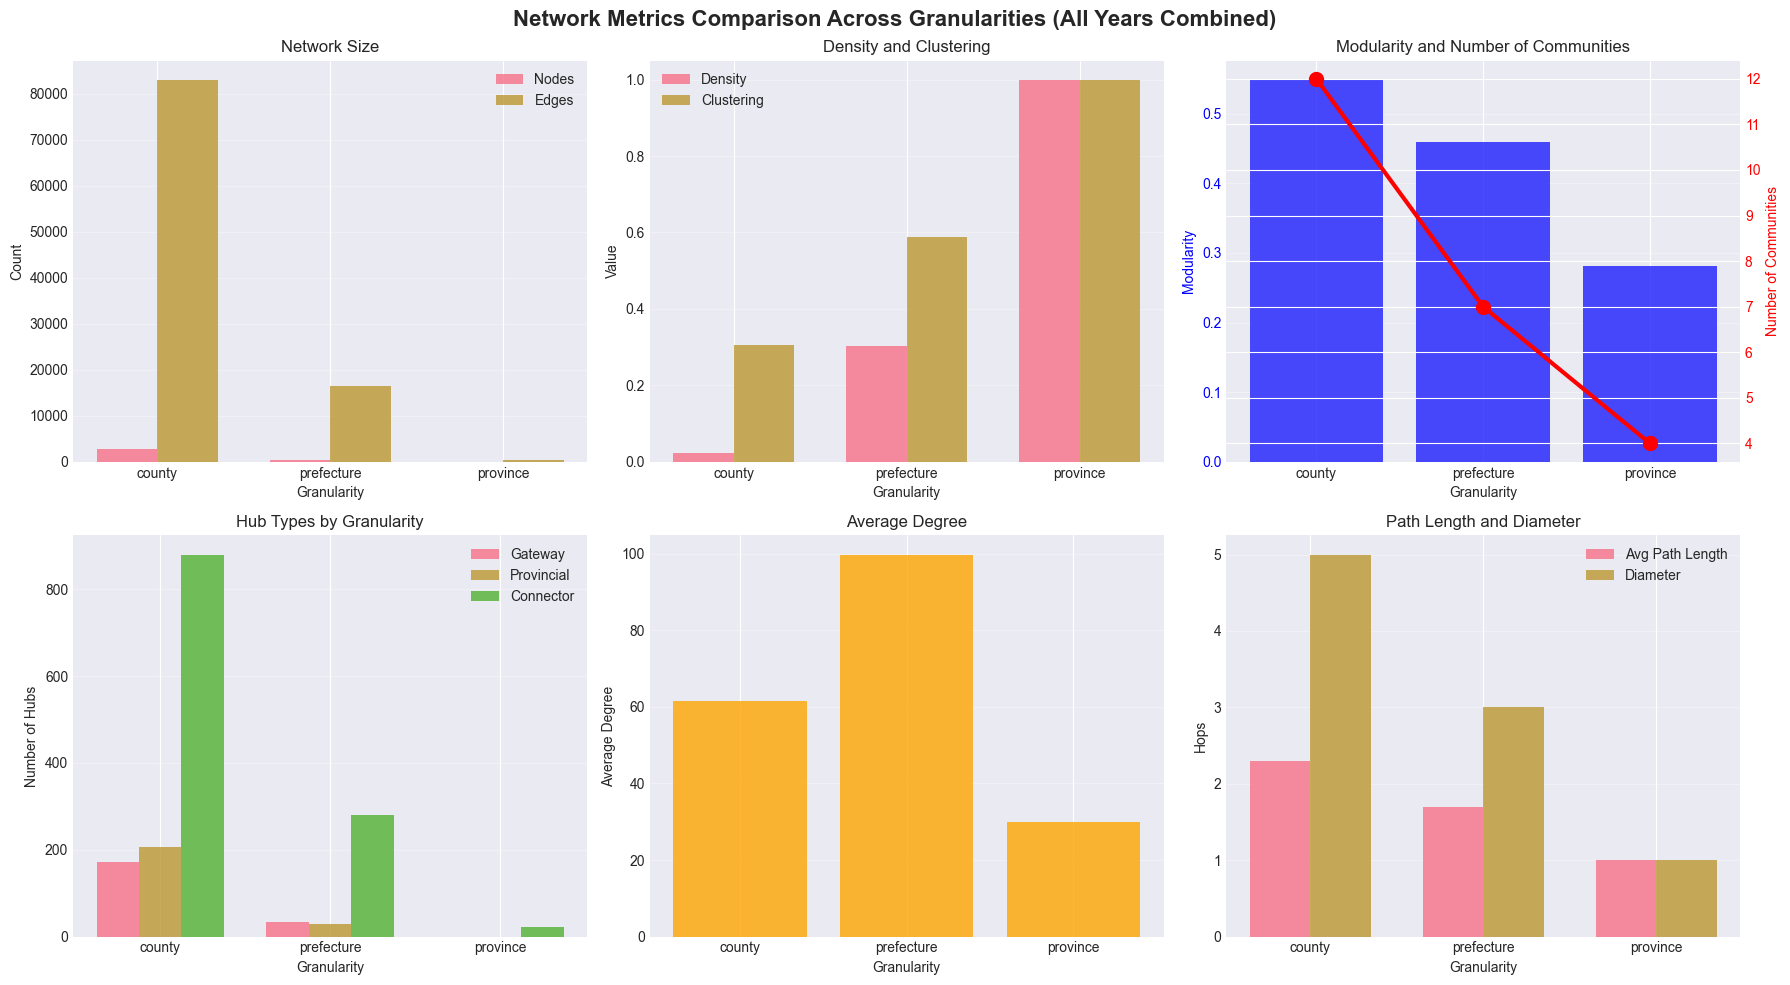

In [8]:
# Filter for aggregate data (all years combined)
aggregate_df = metrics_df[metrics_df['years'] == 'all'].copy()

# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Network Metrics Comparison Across Granularities (All Years Combined)', 
             fontsize=16, fontweight='bold')

# 1. Network size
ax = axes[0, 0]
x = range(len(aggregate_df))
width = 0.35
ax.bar([i - width/2 for i in x], aggregate_df['n_nodes'], width, label='Nodes', alpha=0.8)
ax.bar([i + width/2 for i in x], aggregate_df['n_edges'], width, label='Edges', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Network Size')
ax.set_ylabel('Count')
ax.set_xlabel('Granularity')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Density and clustering
ax = axes[0, 1]
x = range(len(aggregate_df))
width = 0.35
ax.bar([i - width/2 for i in x], aggregate_df['density'], width, label='Density', alpha=0.8)
ax.bar([i + width/2 for i in x], aggregate_df['avg_clustering'], width, label='Clustering', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Density and Clustering')
ax.set_ylabel('Value')
ax.set_xlabel('Granularity')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Modularity and communities
ax = axes[0, 2]
ax2 = ax.twinx()
x = range(len(aggregate_df))
ax.bar(x, aggregate_df['modularity'], color='blue', alpha=0.7, label='Modularity')
ax2.plot(x, aggregate_df['n_communities'], color='red', marker='o', 
         markersize=10, linewidth=3, label='Communities')
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Modularity and Number of Communities')
ax.set_ylabel('Modularity', color='blue')
ax2.set_ylabel('Number of Communities', color='red')
ax.set_xlabel('Granularity')
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
ax.grid(axis='y', alpha=0.3)

# 4. Hub counts
ax = axes[1, 0]
x = range(len(aggregate_df))
width = 0.25
ax.bar([i - width for i in x], aggregate_df['n_gateway_hubs'], width, 
       label='Gateway', alpha=0.8)
ax.bar(x, aggregate_df['n_provincial_hubs'], width, 
       label='Provincial', alpha=0.8)
ax.bar([i + width for i in x], aggregate_df['n_connector_hubs'], width, 
       label='Connector', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Hub Types by Granularity')
ax.set_ylabel('Number of Hubs')
ax.set_xlabel('Granularity')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 5. Average degree
ax = axes[1, 1]
x = range(len(aggregate_df))
ax.bar(x, aggregate_df['avg_degree'], alpha=0.8, color='orange')
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Average Degree')
ax.set_ylabel('Average Degree')
ax.set_xlabel('Granularity')
ax.grid(axis='y', alpha=0.3)

# 6. Average path length and diameter
ax = axes[1, 2]
x = range(len(aggregate_df))
width = 0.35
ax.bar([i - width/2 for i in x], aggregate_df['avg_path_length'], width, 
       label='Avg Path Length', alpha=0.8)
ax.bar([i + width/2 for i in x], aggregate_df['diameter'], width, 
       label='Diameter', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(aggregate_df['granularity'])
ax.set_title('Path Length and Diameter')
ax.set_ylabel('Hops')
ax.set_xlabel('Granularity')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Visualization: Temporal Evolution by Granularity

Visualize how metrics evolve over time for each granularity level.

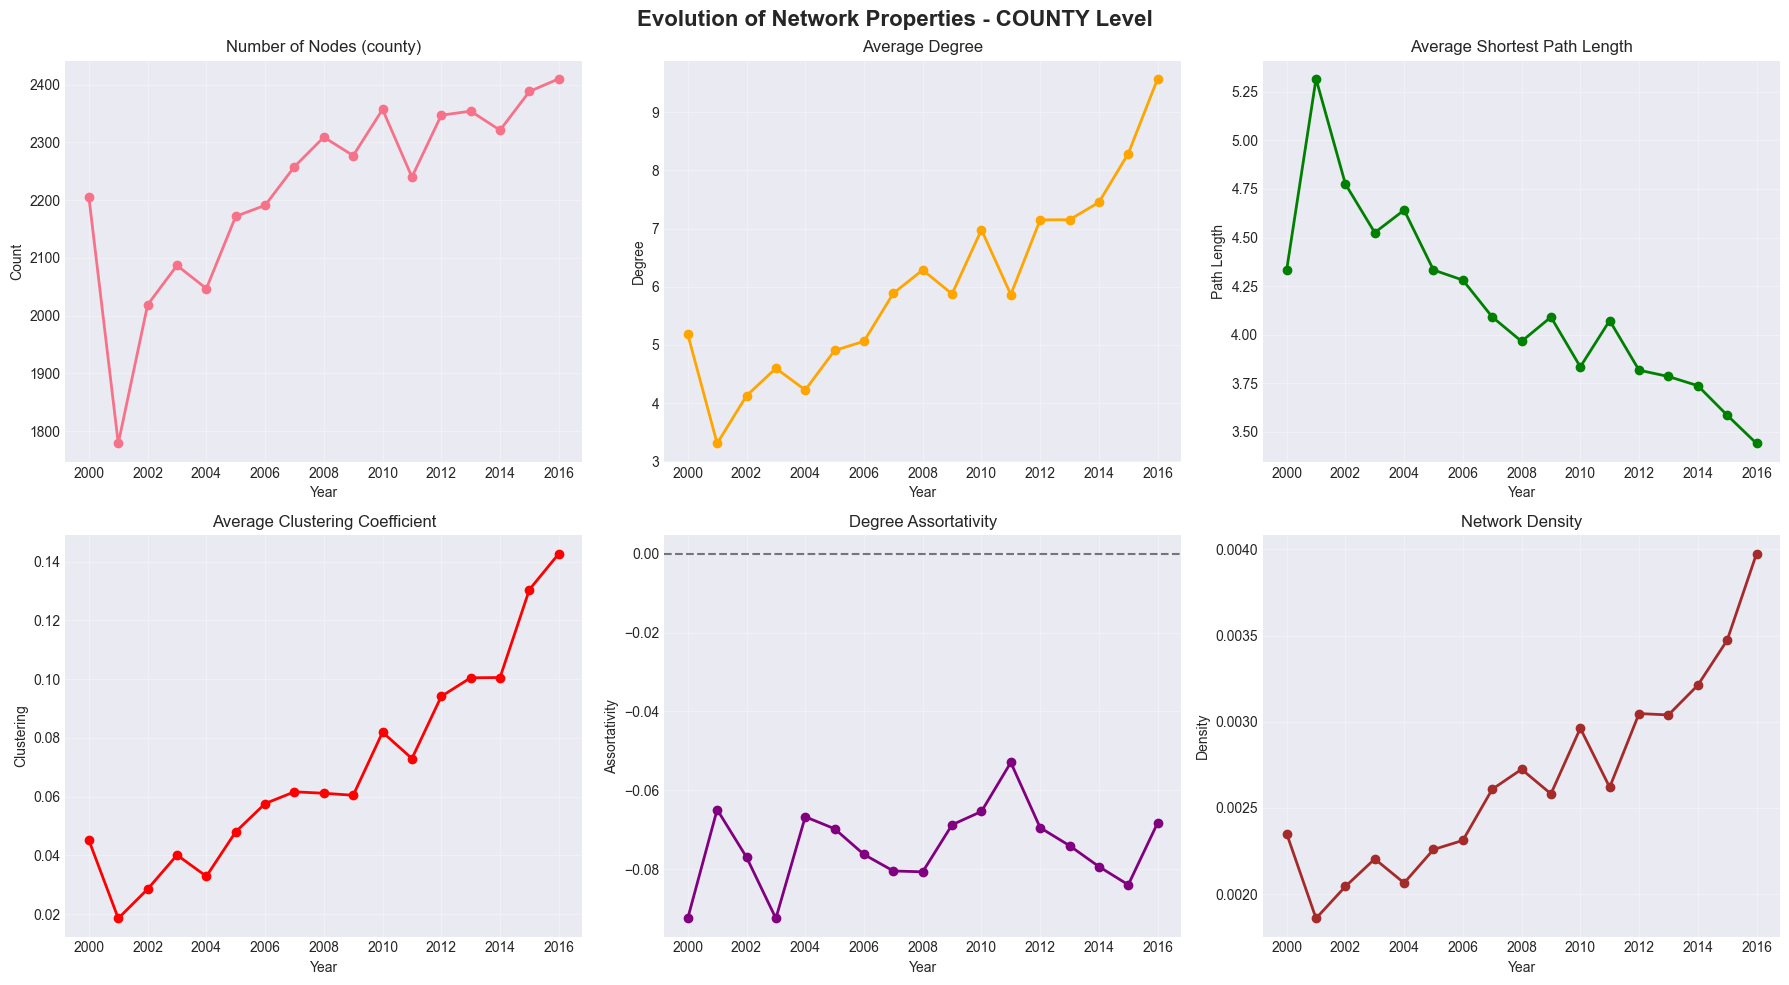

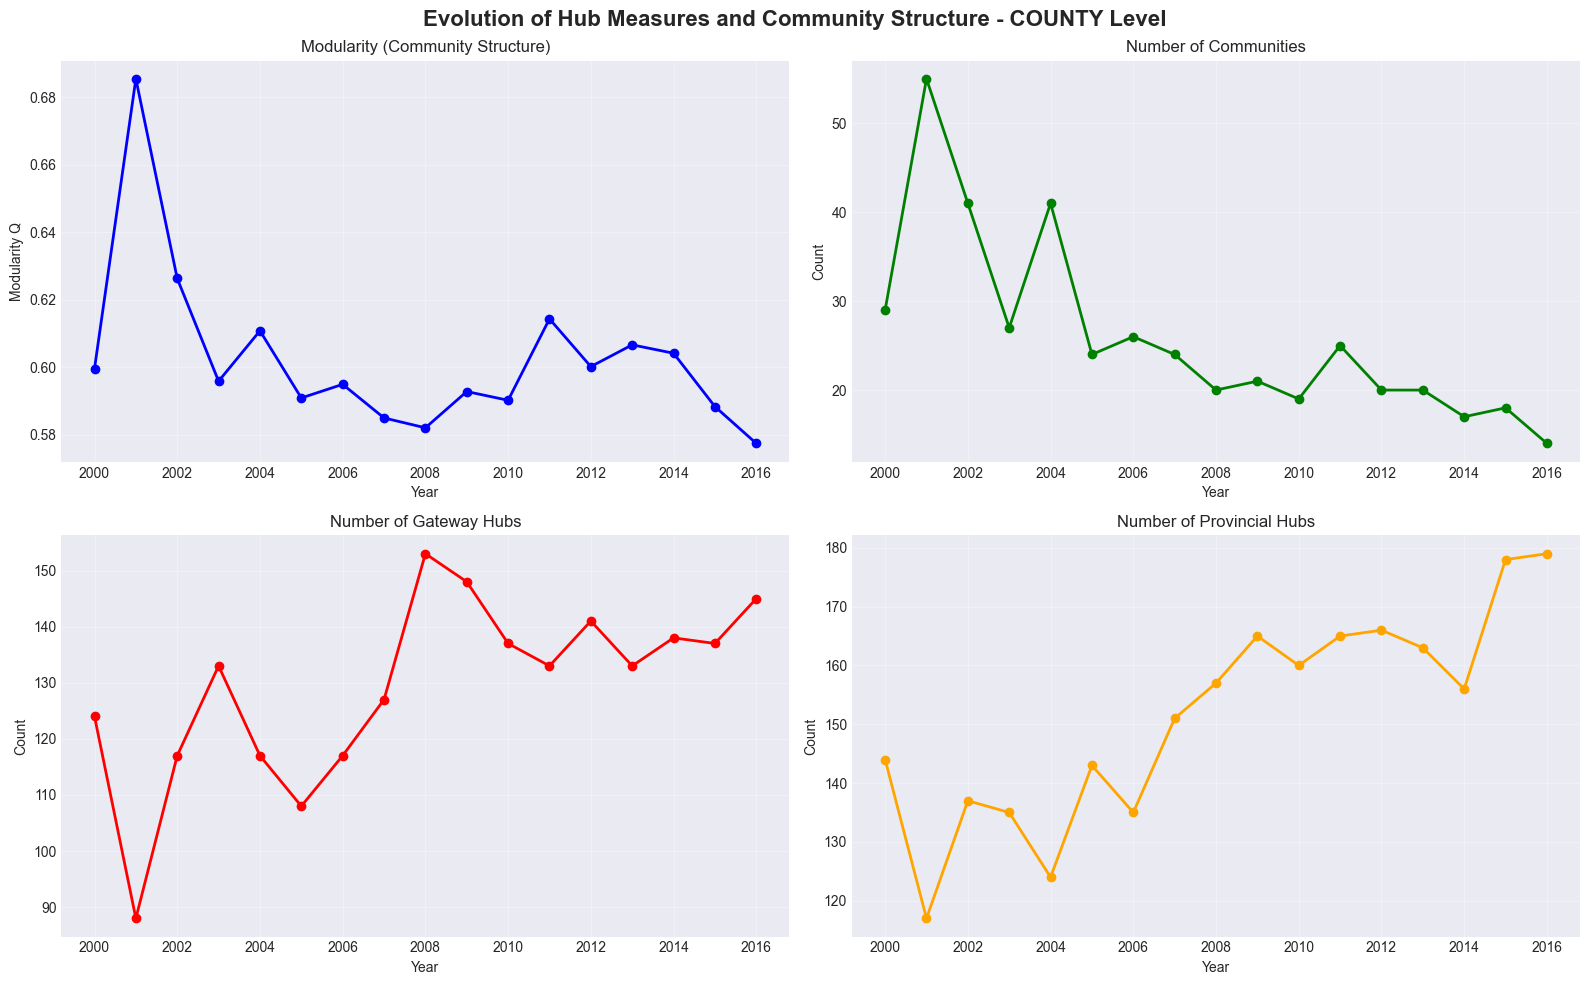

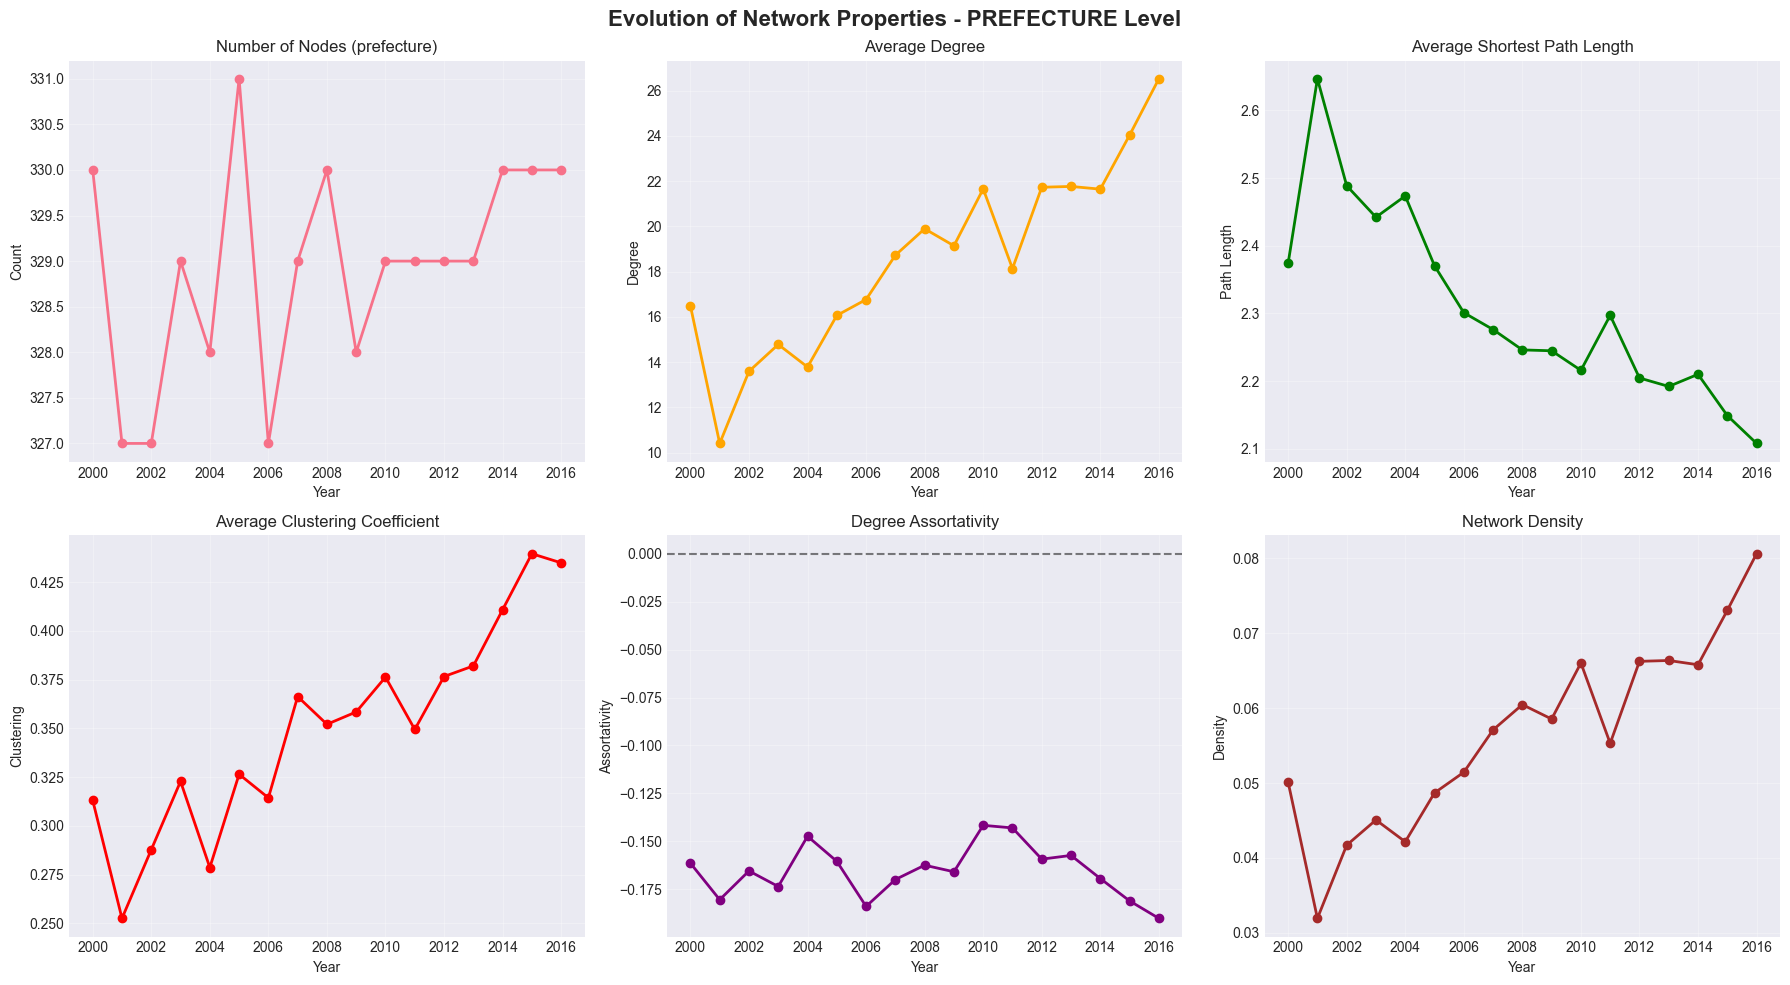

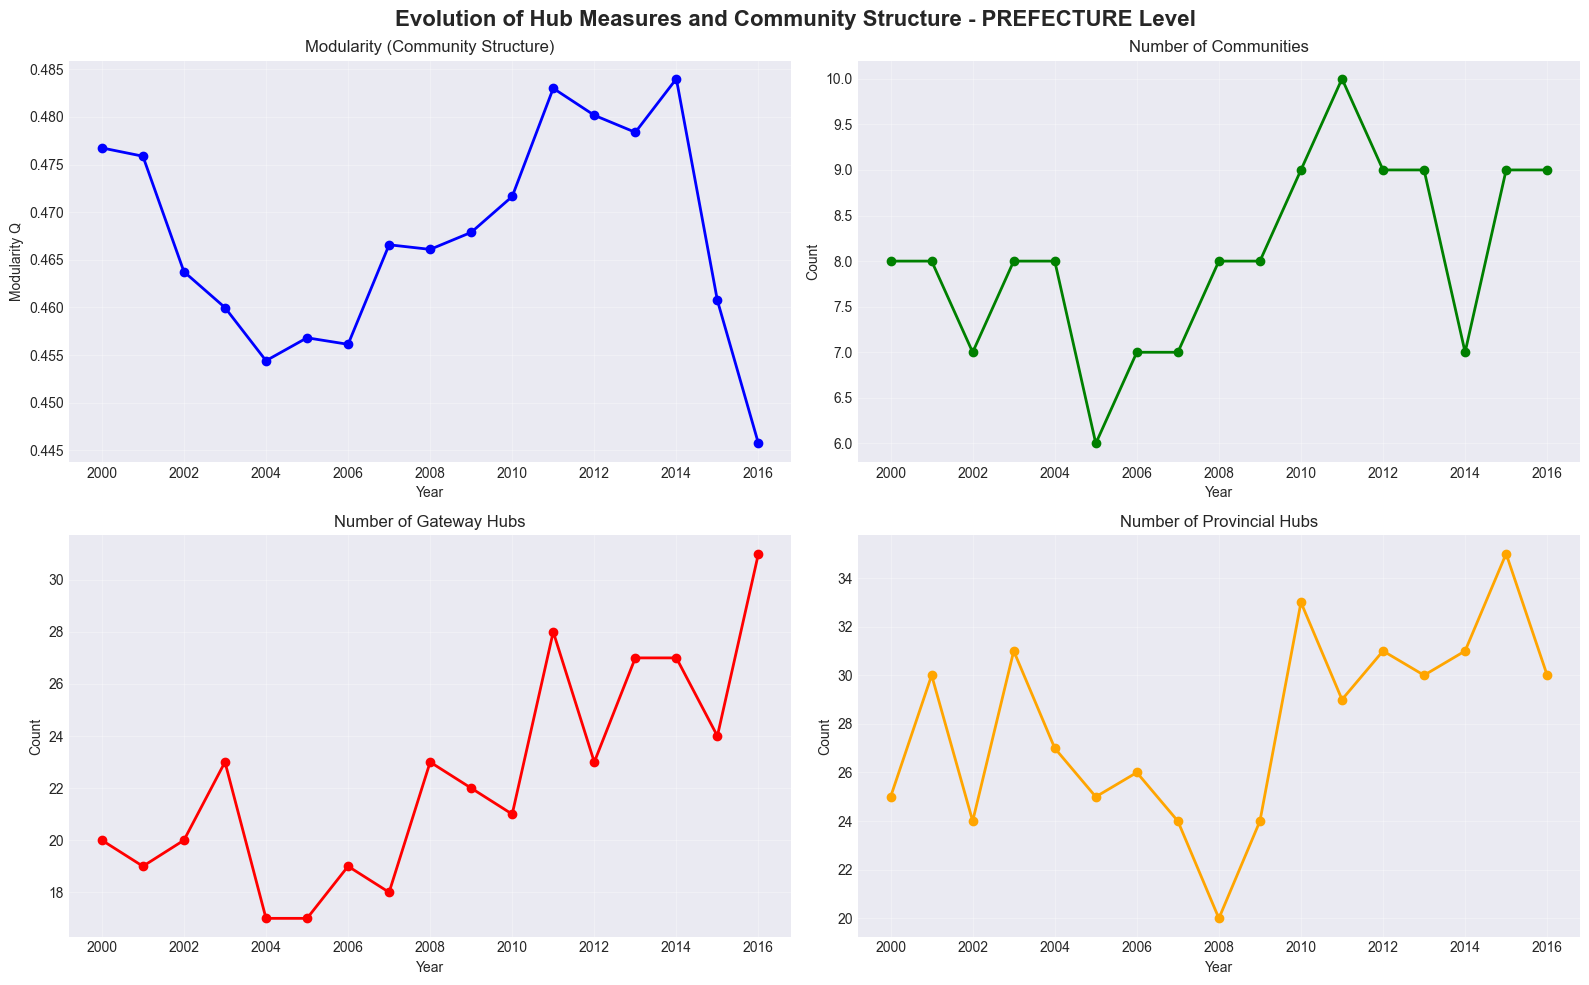

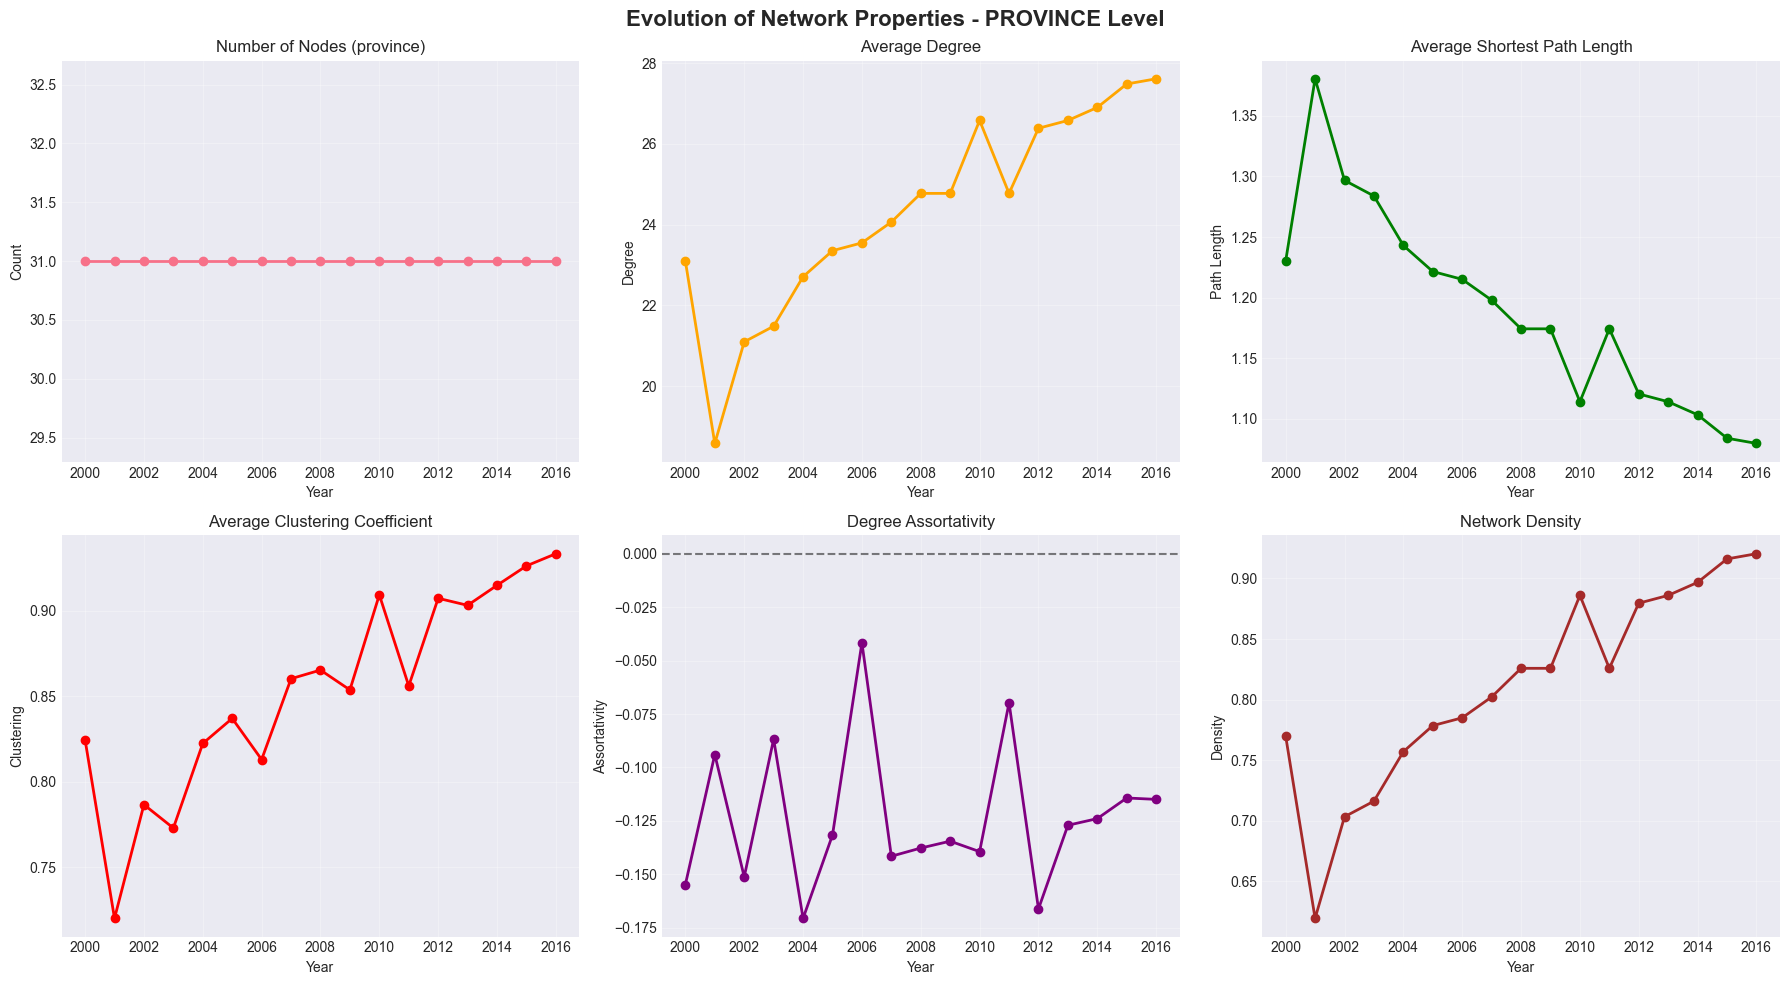

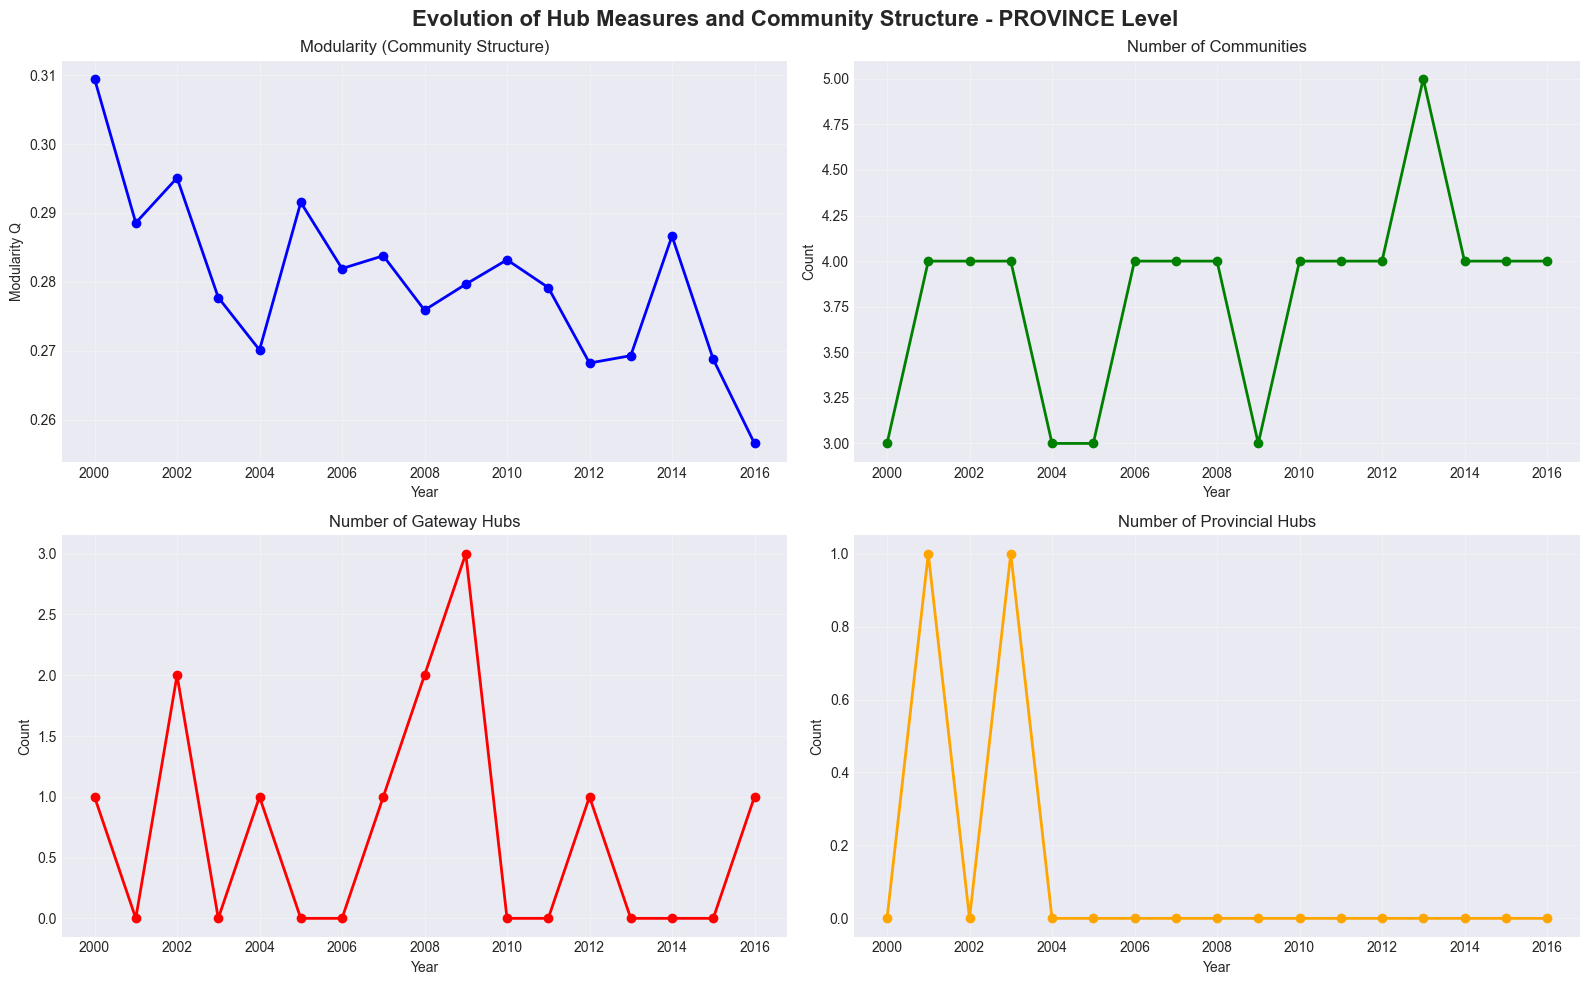

In [10]:
# Filter for temporal data (individual years)
if 'year' in metrics_df.columns:
    temporal_df = metrics_df[metrics_df['years'] != 'all'].copy()
    
    if len(temporal_df) > 0:
        # Create temporal evolution plots - one figure per granularity
        for granularity in granularities:
            gran_df = temporal_df[temporal_df['granularity'] == granularity].sort_values('year')
            
            if len(gran_df) > 0:
                # Set year as index for easier plotting
                gran_df_indexed = gran_df.set_index('year')
                
                # Create time series plots (same style as enhanced_china_migration_analysis)
                fig, axes = plt.subplots(2, 3, figsize=(18, 10))
                fig.suptitle(f'Evolution of Network Properties - {granularity.upper()} Level', 
                             fontsize=16, fontweight='bold')
                
                # 1. Network size (Number of nodes)
                ax = axes[0, 0]
                gran_df_indexed['n_nodes'].plot(ax=ax, marker='o', linewidth=2)
                ax.set_title(f'Number of Nodes ({granularity})')
                ax.set_xlabel('Year')
                ax.set_ylabel('Count')
                ax.grid(alpha=0.3)
                
                # 2. Average degree
                ax = axes[0, 1]
                gran_df_indexed['avg_degree'].plot(ax=ax, marker='o', linewidth=2, color='orange')
                ax.set_title('Average Degree')
                ax.set_xlabel('Year')
                ax.set_ylabel('Degree')
                ax.grid(alpha=0.3)
                
                # 3. Average path length
                ax = axes[0, 2]
                gran_df_indexed['avg_path_length'].plot(ax=ax, marker='o', linewidth=2, color='green')
                ax.set_title('Average Shortest Path Length')
                ax.set_xlabel('Year')
                ax.set_ylabel('Path Length')
                ax.grid(alpha=0.3)
                
                # 4. Clustering coefficient
                ax = axes[1, 0]
                gran_df_indexed['avg_clustering'].plot(ax=ax, marker='o', linewidth=2, color='red')
                ax.set_title('Average Clustering Coefficient')
                ax.set_xlabel('Year')
                ax.set_ylabel('Clustering')
                ax.grid(alpha=0.3)
                
                # 5. Assortativity
                ax = axes[1, 1]
                gran_df_indexed['assortativity'].plot(ax=ax, marker='o', linewidth=2, color='purple')
                ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
                ax.set_title('Degree Assortativity')
                ax.set_xlabel('Year')
                ax.set_ylabel('Assortativity')
                ax.grid(alpha=0.3)
                
                # 6. Density
                ax = axes[1, 2]
                gran_df_indexed['density'].plot(ax=ax, marker='o', linewidth=2, color='brown')
                ax.set_title('Network Density')
                ax.set_xlabel('Year')
                ax.set_ylabel('Density')
                ax.grid(alpha=0.3)
                
                plt.tight_layout()
                plt.show()
                
                # Second figure: Hub measures and modularity
                fig, axes = plt.subplots(2, 2, figsize=(16, 10))
                fig.suptitle(f'Evolution of Hub Measures and Community Structure - {granularity.upper()} Level', 
                             fontsize=16, fontweight='bold')
                
                # 1. Modularity
                ax = axes[0, 0]
                gran_df_indexed['modularity'].plot(ax=ax, marker='o', linewidth=2, color='blue')
                ax.set_title('Modularity (Community Structure)')
                ax.set_xlabel('Year')
                ax.set_ylabel('Modularity Q')
                ax.grid(alpha=0.3)
                
                # 2. Number of communities
                ax = axes[0, 1]
                gran_df_indexed['n_communities'].plot(ax=ax, marker='o', linewidth=2, color='green')
                ax.set_title('Number of Communities')
                ax.set_xlabel('Year')
                ax.set_ylabel('Count')
                ax.grid(alpha=0.3)
                
                # 3. Gateway hubs
                ax = axes[1, 0]
                gran_df_indexed['n_gateway_hubs'].plot(ax=ax, marker='o', linewidth=2, color='red')
                ax.set_title('Number of Gateway Hubs')
                ax.set_xlabel('Year')
                ax.set_ylabel('Count')
                ax.grid(alpha=0.3)
                
                # 4. Provincial hubs
                ax = axes[1, 1]
                gran_df_indexed['n_provincial_hubs'].plot(ax=ax, marker='o', linewidth=2, color='orange')
                ax.set_title('Number of Provincial Hubs')
                ax.set_xlabel('Year')
                ax.set_ylabel('Count')
                ax.grid(alpha=0.3)
                
                plt.tight_layout()
                plt.show()
    else:
        print("No temporal data available. Set year_list parameter to compute metrics for individual years.")
else:
    print("No temporal data available. Set year_list parameter to compute metrics for individual years.")

## Detailed Hub Analysis: Global and Temporal

Now let's analyze the top 10 hub cities in detail, both for the global network (all years combined) and for temporal evolution (each year).

In [11]:
# ============================================================================
# PART 1: GLOBAL HUB ANALYSIS (ALL YEARS COMBINED)
# ============================================================================

print("\n" + "="*80)
print("GLOBAL HUB ANALYSIS - PREFECTURE LEVEL (ALL YEARS COMBINED)")
print("="*80)

# Create global graph for prefecture level
G_global = create_undirected_graph(granularity='prefecture', years=None)

print(f"\nGlobal network: {G_global.number_of_nodes()} nodes, {G_global.number_of_edges()} edges")

# Detect communities
print("\nDetecting communities in global network...")
partition_global, modularity_global = detect_communities(G_global)
n_communities = len(set(partition_global.values()))
print(f"Number of communities: {n_communities}")
print(f"Modularity Q: {modularity_global:.3f}")

# Compute hub measures
print("\nComputing hub measures for global network...")
hub_measures_global = compute_hub_measures(G_global, partition_global)

# Print top 10 cities by each measure
print("\n" + "="*80)
print("=== Top 10 Cities by Gateway-ness (B) - GLOBAL ===")
print("="*80)
top_B_global = sorted(hub_measures_global.items(), key=lambda x: x[1]['B'], reverse=True)[:10]
for i, (city, measures) in enumerate(top_B_global, 1):
    print(f"{i:2d}. {city:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

print("\n" + "="*80)
print("=== Top 10 Cities by Provincial-ness (Z) - GLOBAL ===")
print("="*80)
top_Z_global = sorted(hub_measures_global.items(), key=lambda x: x[1]['Z'], reverse=True)[:10]
for i, (city, measures) in enumerate(top_Z_global, 1):
    print(f"{i:2d}. {city:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

print("\n" + "="*80)
print("=== Top 10 Cities by Connector-ness (P) - GLOBAL ===")
print("="*80)
top_P_global = sorted(hub_measures_global.items(), key=lambda x: x[1]['P'], reverse=True)[:10]
for i, (city, measures) in enumerate(top_P_global, 1):
    print(f"{i:2d}. {city:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")

# Classify hubs in global network
classification_global = classify_hubs(hub_measures_global)
print("\n" + "="*80)
print("Global Hub Classification:")
print(f"  Gateway hubs (B ≥ 1.5): {len(classification_global['gateway'])}")
print(f"  Provincial hubs (Z ≥ 1.5): {len(classification_global['provincial'])}")
print(f"  Connector hubs (P ≥ 0.7): {len(classification_global['connector'])}")
print("="*80)


GLOBAL HUB ANALYSIS - PREFECTURE LEVEL (ALL YEARS COMBINED)

Global network: 331 nodes, 16518 edges

Detecting communities in global network...
Number of communities: 7
Modularity Q: 0.460

Computing hub measures for global network...

=== Top 10 Cities by Gateway-ness (B) - GLOBAL ===
 1. 1101                     : B=  3.72, Z=  2.27, P=  0.84
 2. 4403                     : B=  3.67, Z=  2.36, P=  0.83
 3. 4401                     : B=  3.33, Z=  2.36, P=  0.82
 4. 5001                     : B=  3.30, Z=  2.38, P=  0.82
 5. 2101                     : B=  3.28, Z=  1.83, P=  0.83
 6. 1201                     : B=  3.16, Z=  2.08, P=  0.84
 7. 6101                     : B=  2.99, Z=  1.50, P=  0.83
 8. 3101                     : B=  2.82, Z=  1.51, P=  0.83
 9. 6201                     : B=  2.56, Z=  1.90, P=  0.83
10. 3505                     : B=  2.46, Z=  1.68, P=  0.80

=== Top 10 Cities by Provincial-ness (Z) - GLOBAL ===
 1. 5001                     : B=  3.30, Z=  2.38, P=  0.

In [12]:
# ============================================================================
# PART 2: TEMPORAL HUB ANALYSIS (YEAR BY YEAR)
# ============================================================================

print("\n" + "="*80)
print("TEMPORAL HUB ANALYSIS - YEAR BY YEAR")
print("="*80)

# Define years to analyze
years_to_analyze = [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
                    2010, 2011, 2012, 2013, 2014, 2015, 2016]

# Compute hub measures for all years
yearly_hub_measures = {}
yearly_modularity = {}
yearly_top10_B = {}
yearly_top10_Z = {}
yearly_top10_P = {}
yearly_hub_classification = {}

print("\nComputing hub measures for each year...")
for year in tqdm(years_to_analyze):
    G = create_undirected_graph(granularity='prefecture', years=[year])
    
    if G.number_of_nodes() > 10:
        partition, modularity = detect_communities(G)
        hub_measures = compute_hub_measures(G, partition)
        
        yearly_hub_measures[year] = hub_measures
        yearly_modularity[year] = modularity
        
        # Get top 10 for each measure
        top_B = sorted(hub_measures.items(), key=lambda x: x[1]['B'], reverse=True)[:10]
        top_Z = sorted(hub_measures.items(), key=lambda x: x[1]['Z'], reverse=True)[:10]
        top_P = sorted(hub_measures.items(), key=lambda x: x[1]['P'], reverse=True)[:10]
        
        yearly_top10_B[year] = top_B
        yearly_top10_Z[year] = top_Z
        yearly_top10_P[year] = top_P
        
        # Classify hubs
        classification = classify_hubs(hub_measures)
        yearly_hub_classification[year] = classification
        
        n_communities = len(set(partition.values()))

print("\n✓ Computed hub measures for all years!")

# Print top 10 for selected years
selected_years = [2000, 2005, 2010, 2015, 2016]

for year in selected_years:
    if year in yearly_top10_B:
        print("\n" + "="*80)
        print(f"YEAR {year}")
        print("="*80)
        
        print("\n--- Top 10 Cities by Gateway-ness (B) ---")
        for i, (city, measures) in enumerate(yearly_top10_B[year], 1):
            print(f"{i:2d}. {city:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")
        
        print("\n--- Top 10 Cities by Provincial-ness (Z) ---")
        for i, (city, measures) in enumerate(yearly_top10_Z[year], 1):
            print(f"{i:2d}. {city:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")
        
        print("\n--- Top 10 Cities by Connector-ness (P) ---")
        for i, (city, measures) in enumerate(yearly_top10_P[year], 1):
            print(f"{i:2d}. {city:25s}: B={measures['B']:6.2f}, Z={measures['Z']:6.2f}, P={measures['P']:6.2f}")


TEMPORAL HUB ANALYSIS - YEAR BY YEAR

Computing hub measures for each year...


100%|██████████| 17/17 [01:59<00:00,  7.05s/it]


✓ Computed hub measures for all years!

YEAR 2000

--- Top 10 Cities by Gateway-ness (B) ---
 1. 1101                     : B=  7.42, Z=  5.06, P=  0.79
 2. 4403                     : B=  5.73, Z=  5.75, P=  0.69
 3. 3101                     : B=  4.86, Z=  3.80, P=  0.76
 4. 5001                     : B=  4.59, Z=  3.28, P=  0.78
 5. 4401                     : B=  4.19, Z=  4.48, P=  0.67
 6. 6101                     : B=  3.90, Z=  2.87, P=  0.79
 7. 1401                     : B=  3.48, Z=  2.69, P=  0.77
 8. 6501                     : B=  3.06, Z=  2.87, P=  0.77
 9. 1201                     : B=  2.88, Z=  3.53, P=  0.71
10. 3303                     : B=  2.60, Z=  1.19, P=  0.77

--- Top 10 Cities by Provincial-ness (Z) ---
 1. 4403                     : B=  5.73, Z=  5.75, P=  0.69
 2. 1101                     : B=  7.42, Z=  5.06, P=  0.79
 3. 4401                     : B=  4.19, Z=  4.48, P=  0.67
 4. 3101                     : B=  4.86, Z=  3.80, P=  0.76
 5. 1201            


GENERATING VISUALIZATIONS

Major cities (appear in ≥15 years): 327

Tracking top 10 cities by average Gateway-ness:
   1. 1101                     : Average B = 6.20
   2. 4403                     : Average B = 5.36
   3. 3101                     : Average B = 4.90
   4. 4401                     : Average B = 4.25
   5. 6101                     : Average B = 4.10
   6. 5001                     : Average B = 3.73
   7. 1201                     : Average B = 2.89
   8. 3505                     : Average B = 2.78
   9. 3303                     : Average B = 2.40
  10. 2101                     : Average B = 2.39


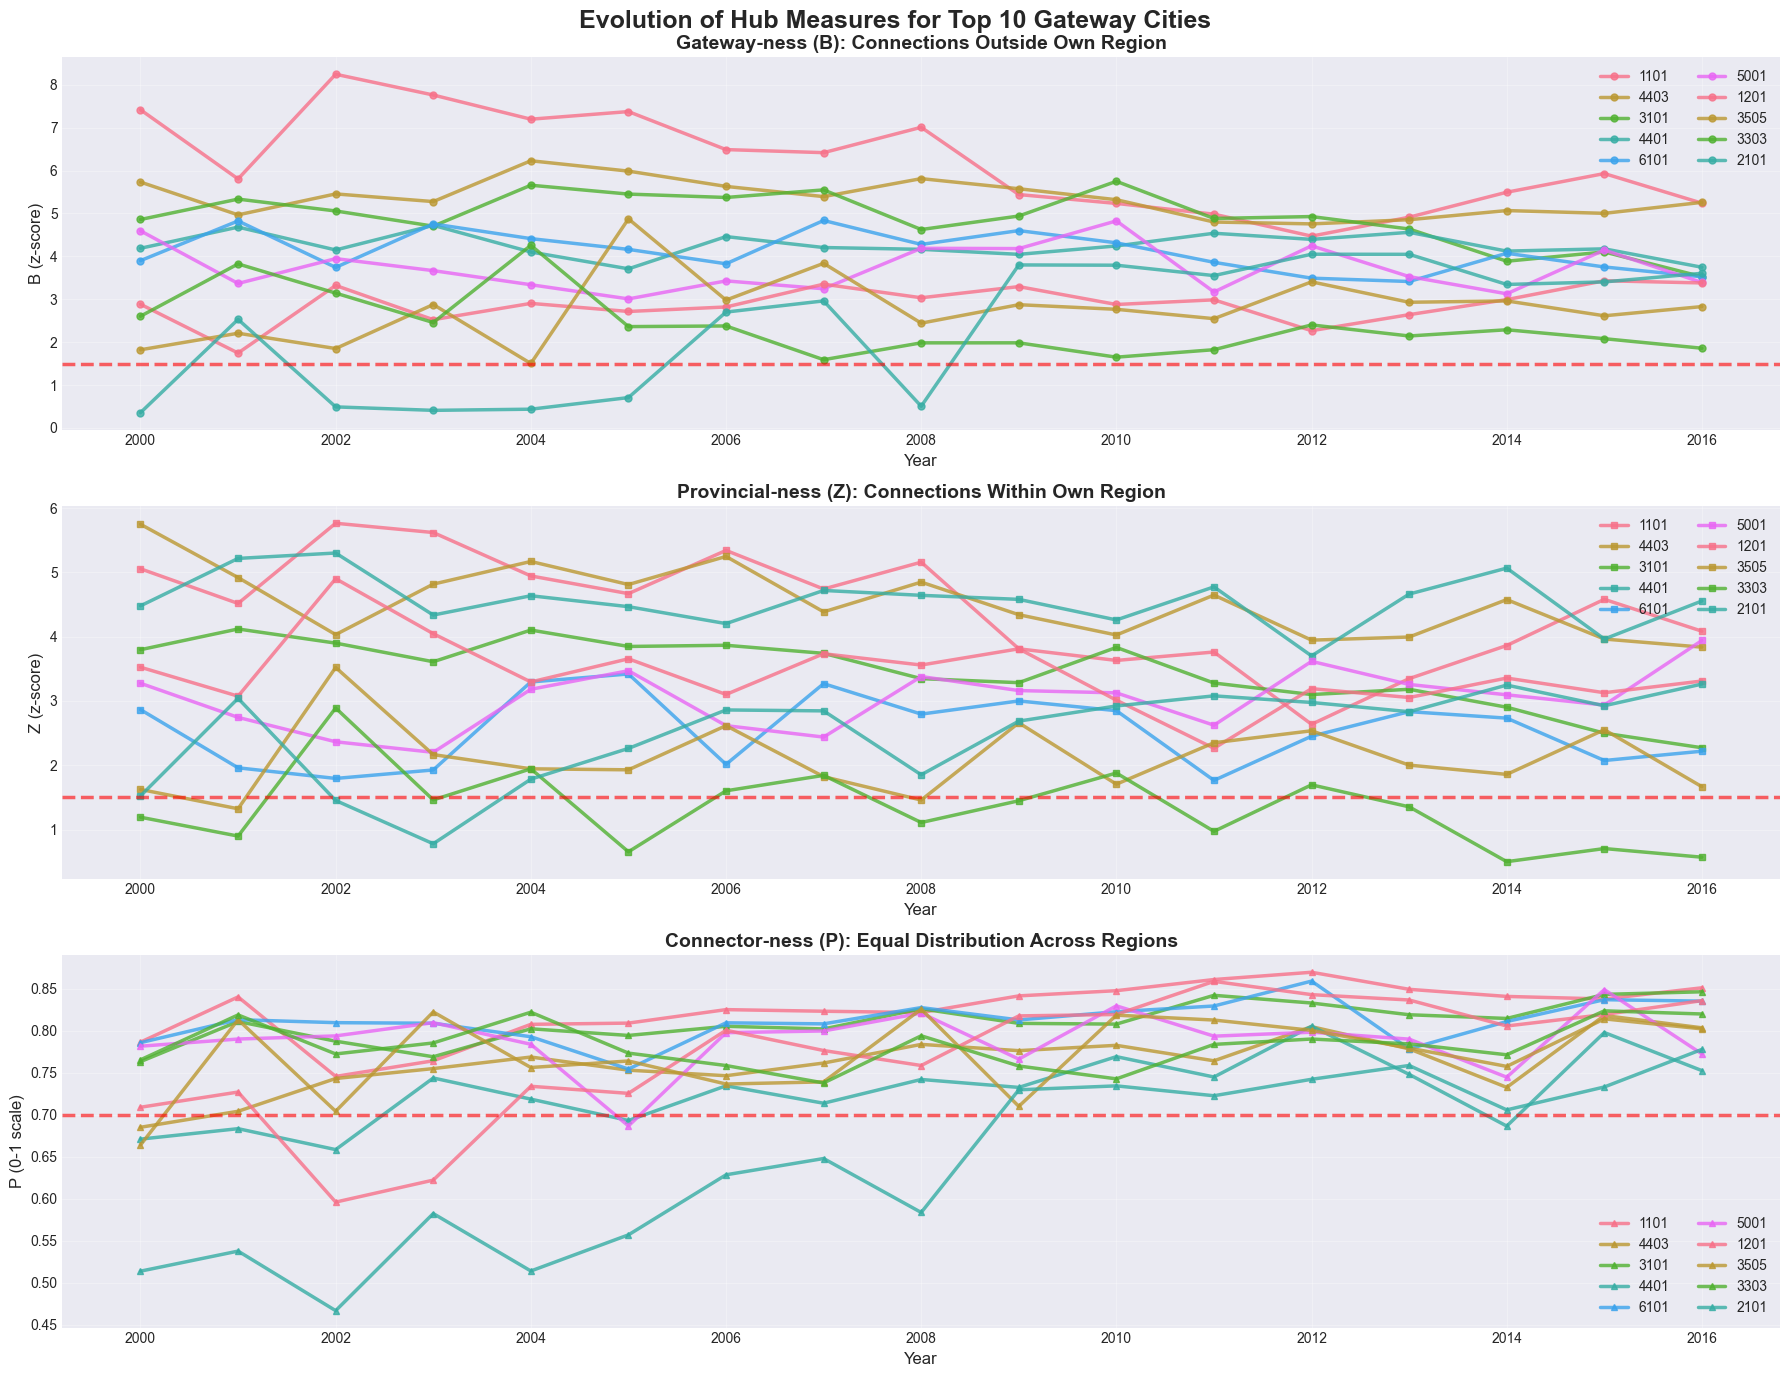

In [13]:
# ============================================================================
# PART 3: VISUALIZATION - EVOLUTION OF TOP CITIES
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Select major cities that appear frequently
city_counts = defaultdict(int)
city_avg_B = defaultdict(list)

for year, measures in yearly_hub_measures.items():
    for city, vals in measures.items():
        city_counts[city] += 1
        city_avg_B[city].append(vals['B'])

# Get cities that appear in at least 15 years
major_cities = [city for city, count in city_counts.items() if count >= 15]
print(f"\nMajor cities (appear in ≥15 years): {len(major_cities)}")

# Calculate average B for each major city
city_avg_B_score = {city: np.mean(city_avg_B[city]) for city in major_cities}
top_cities = sorted(city_avg_B_score.items(), key=lambda x: x[1], reverse=True)[:10]
cities_to_track = [city for city, _ in top_cities]

print(f"\nTracking top 10 cities by average Gateway-ness:")
for i, (city, avg_b) in enumerate(top_cities, 1):
    print(f"  {i:2d}. {city:25s}: Average B = {avg_b:.2f}")

# Extract time series for each measure
city_B_series = {city: [] for city in cities_to_track}
city_Z_series = {city: [] for city in cities_to_track}
city_P_series = {city: [] for city in cities_to_track}
years_available = []

for year in sorted(yearly_hub_measures.keys()):
    measures = yearly_hub_measures[year]
    years_available.append(year)
    
    for city in cities_to_track:
        if city in measures:
            city_B_series[city].append(measures[city]['B'])
            city_Z_series[city].append(measures[city]['Z'])
            city_P_series[city].append(measures[city]['P'])
        else:
            city_B_series[city].append(np.nan)
            city_Z_series[city].append(np.nan)
            city_P_series[city].append(np.nan)

# Plot evolution with enhanced styling
fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('Evolution of Hub Measures for Top 10 Gateway Cities', fontsize=18, fontweight='bold')

# Gateway-ness
ax = axes[0]
for city in cities_to_track:
    ax.plot(years_available, city_B_series[city], marker='o', label=city, linewidth=2.5, markersize=5, alpha=0.8)
ax.set_title('Gateway-ness (B): Connections Outside Own Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('B (z-score)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=1.5, color='red', linestyle='--', alpha=0.6, linewidth=2.5, label='Gateway hub threshold')

# Provincial-ness
ax = axes[1]
for city in cities_to_track:
    ax.plot(years_available, city_Z_series[city], marker='s', label=city, linewidth=2.5, markersize=5, alpha=0.8)
ax.set_title('Provincial-ness (Z): Connections Within Own Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Z (z-score)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=1.5, color='red', linestyle='--', alpha=0.6, linewidth=2.5, label='Provincial hub threshold')

# Connector-ness
ax = axes[2]
for city in cities_to_track:
    ax.plot(years_available, city_P_series[city], marker='^', label=city, linewidth=2.5, markersize=5, alpha=0.8)
ax.set_title('Connector-ness (P): Equal Distribution Across Regions', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('P (0-1 scale)', fontsize=12)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.6, linewidth=2.5, label='Connector hub threshold')

plt.tight_layout()
plt.show()

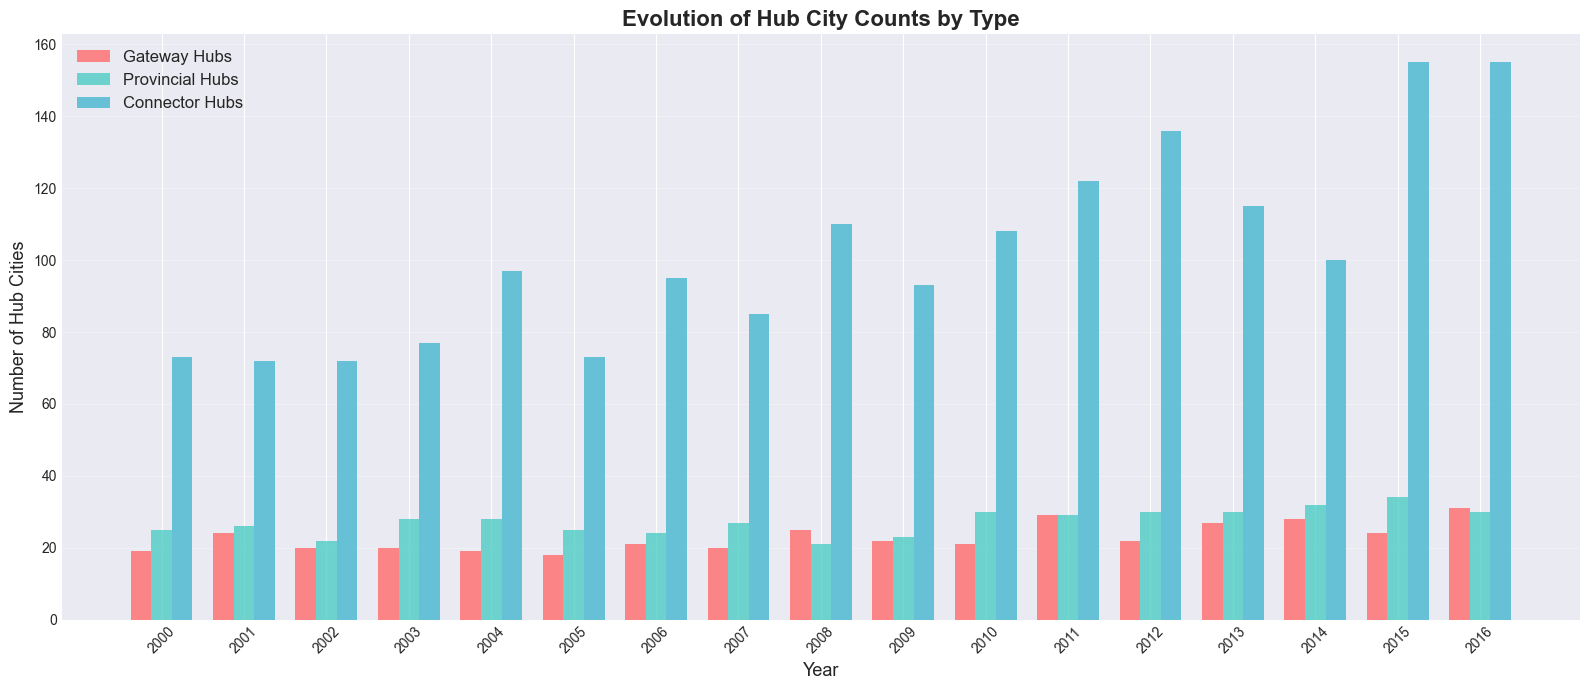


HUB COUNTS SUMMARY

Gateway Hubs:
  Min: 18, Max: 31, Avg: 22.9

Provincial Hubs:
  Min: 21, Max: 34, Avg: 27.3

Connector Hubs:
  Min: 72, Max: 155, Avg: 102.2


In [14]:
# ============================================================================
# PART 4: HUB COUNTS EVOLUTION BAR CHART
# ============================================================================

# Plot evolution of hub counts
hub_counts_data = {
    'Gateway': [],
    'Provincial': [],
    'Connector': []
}

years_list = sorted(yearly_hub_classification.keys())
for year in years_list:
    classification = yearly_hub_classification[year]
    hub_counts_data['Gateway'].append(len(classification['gateway']))
    hub_counts_data['Provincial'].append(len(classification['provincial']))
    hub_counts_data['Connector'].append(len(classification['connector']))

fig, ax = plt.subplots(figsize=(16, 7))
width = 0.25
x = np.arange(len(years_list))

ax.bar(x - width, hub_counts_data['Gateway'], width, label='Gateway Hubs', alpha=0.8, color='#FF6B6B')
ax.bar(x, hub_counts_data['Provincial'], width, label='Provincial Hubs', alpha=0.8, color='#4ECDC4')
ax.bar(x + width, hub_counts_data['Connector'], width, label='Connector Hubs', alpha=0.8, color='#45B7D1')

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Number of Hub Cities', fontsize=13)
ax.set_title('Evolution of Hub City Counts by Type', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(years_list, rotation=45)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("HUB COUNTS SUMMARY")
print("="*80)
print(f"\nGateway Hubs:")
print(f"  Min: {min(hub_counts_data['Gateway'])}, Max: {max(hub_counts_data['Gateway'])}, Avg: {np.mean(hub_counts_data['Gateway']):.1f}")
print(f"\nProvincial Hubs:")
print(f"  Min: {min(hub_counts_data['Provincial'])}, Max: {max(hub_counts_data['Provincial'])}, Avg: {np.mean(hub_counts_data['Provincial']):.1f}")
print(f"\nConnector Hubs:")
print(f"  Min: {min(hub_counts_data['Connector'])}, Max: {max(hub_counts_data['Connector'])}, Avg: {np.mean(hub_counts_data['Connector']):.1f}")


Generating heatmaps for temporal evolution...


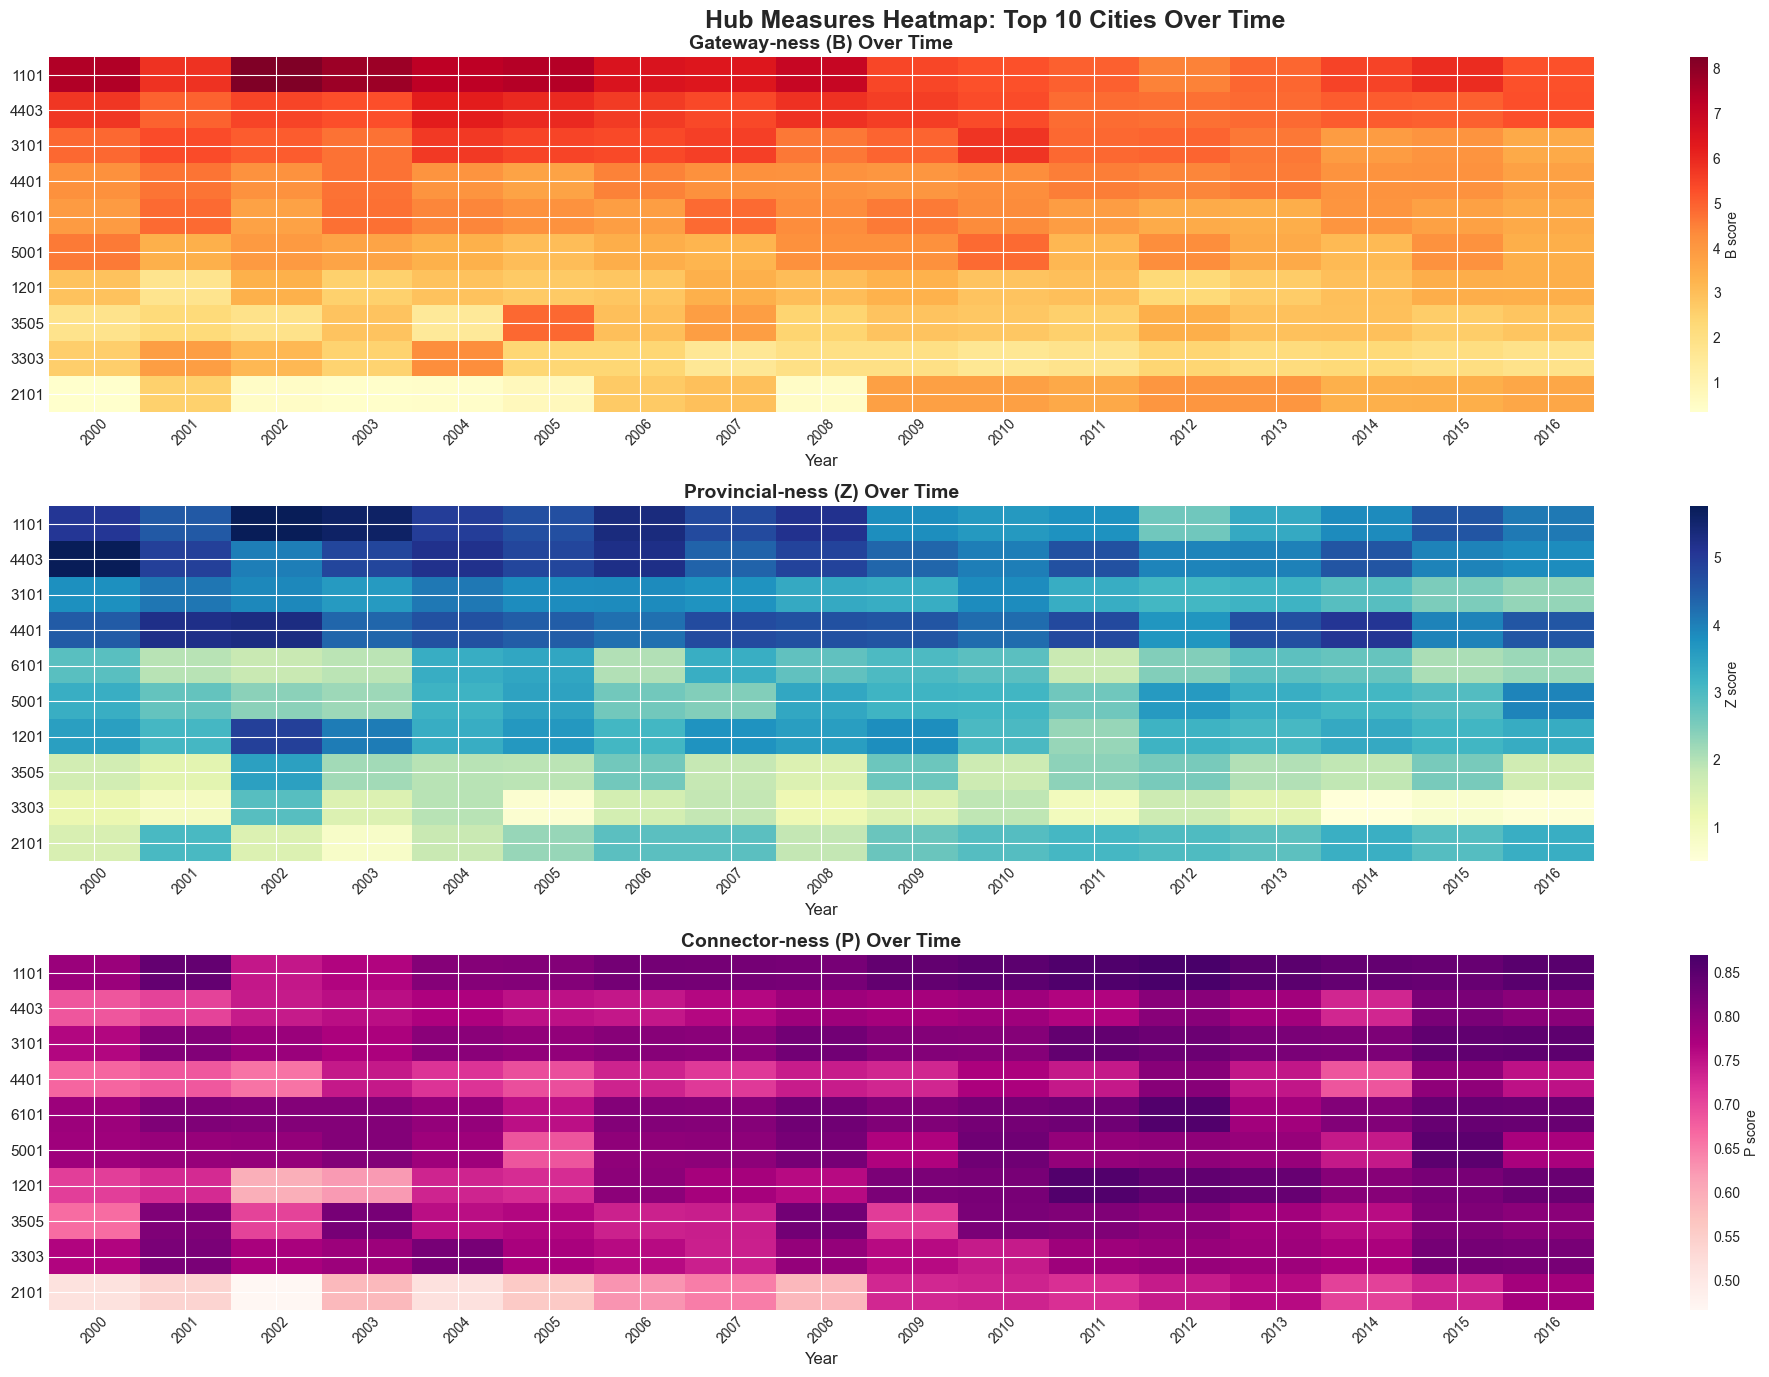


✓ All visualizations complete!


In [15]:
# ============================================================================
# PART 5: HEATMAP VISUALIZATION
# ============================================================================

print("\nGenerating heatmaps for temporal evolution...")

fig, axes = plt.subplots(3, 1, figsize=(20, 14))
fig.suptitle('Hub Measures Heatmap: Top 10 Cities Over Time', fontsize=18, fontweight='bold')

# Prepare data matrices
B_matrix = []
Z_matrix = []
P_matrix = []

for city in cities_to_track:
    B_matrix.append(city_B_series[city])
    Z_matrix.append(city_Z_series[city])
    P_matrix.append(city_P_series[city])

# Gateway-ness heatmap
ax = axes[0]
im = ax.imshow(B_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(len(cities_to_track)))
ax.set_yticklabels(cities_to_track, fontsize=11)
ax.set_xticks(range(len(years_available)))
ax.set_xticklabels(years_available, rotation=45)
ax.set_title('Gateway-ness (B) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='B score')

# Provincial-ness heatmap
ax = axes[1]
im = ax.imshow(Z_matrix, aspect='auto', cmap='YlGnBu', interpolation='nearest')
ax.set_yticks(range(len(cities_to_track)))
ax.set_yticklabels(cities_to_track, fontsize=11)
ax.set_xticks(range(len(years_available)))
ax.set_xticklabels(years_available, rotation=45)
ax.set_title('Provincial-ness (Z) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='Z score')

# Connector-ness heatmap
ax = axes[2]
im = ax.imshow(P_matrix, aspect='auto', cmap='RdPu', interpolation='nearest')
ax.set_yticks(range(len(cities_to_track)))
ax.set_yticklabels(cities_to_track, fontsize=11)
ax.set_xticks(range(len(years_available)))
ax.set_xticklabels(years_available, rotation=45)
ax.set_title('Connector-ness (P) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
plt.colorbar(im, ax=ax, label='P score')

plt.tight_layout()
plt.show()

print("\n✓ All visualizations complete!")

## Summary

This detailed hub analysis provides:

1. **Global Hub Analysis**: Top 10 cities by Gateway-ness (B), Provincial-ness (Z), and Connector-ness (P) across all years combined
2. **Temporal Hub Analysis**: Year-by-year top 10 cities for each hub measure (2000-2016)
3. **Evolution Visualization**: Time series plots showing how the top 10 gateway cities' B, Z, P measures change over time
4. **Hub Counts Evolution**: Bar chart showing the number of gateway, provincial, and connector hubs each year
5. **Heatmap Visualization**: Color-coded temporal evolution of hub measures for top cities

**Key Insights:**
- **Gateway hubs** (B ≥ 1.5): Cities with strong connections outside their own community (e.g., Beijing, Shanghai, Shenzhen)
- **Provincial hubs** (Z ≥ 1.5): Cities dominating within their own community (e.g., regional capitals)
- **Connector hubs** (P ≥ 0.7): Cities with evenly distributed connections across multiple communities